- Интерпретируемая модель машинного обучения 1 и 2 части https://habr.com/ru/companies/otus/articles/464695/
- eli5- https://newtechaudit.ru/biblioteka-eli5-v-prilozhenii-k-zadacham-regressii-i-klassifikaczii/ и https://eli5.readthedocs.io/en/latest/autodocs/eli5.html#eli5.show_prediction
- цвета графиков shap https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Force%20Plot%20Colors.html

### Важность перестановки (Permutation Importance)

In [ ]:
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

Модель предсказывает, будет ли у футбольной команды победитель в номинации «Человек игры» на основе статистики команды. Награда «Человек игры» вручается лучшему игроку в игре. Построение модели не является текущей задачей, поэтому ячейка ниже загружает данные и строит элементарную модель.

In [ ]:
df = pd.read_csv('FIFA 2018 Statistics.csv')

In [ ]:
df.head(2)

,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO,Own goals,Own goal Time
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,0,0,0,Yes,12.0,Group Stage,No,0,NaN,NaN
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,0,0,0,No,NaN,Group Stage,No,0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    128 non-null    object 
 1   Team                    128 non-null    object 
 2   Opponent                128 non-null    object 
 3   Goal Scored             128 non-null    int64  
 4   Ball Possession %       128 non-null    int64  
 5   Attempts                128 non-null    int64  
 6   On-Target               128 non-null    int64  
 7   Off-Target              128 non-null    int64  
 8   Blocked                 128 non-null    int64  
 9   Corners                 128 non-null    int64  
 10  Offsides                128 non-null    int64  
 11  Free Kicks              128 non-null    int64  
 12  Saves                   128 non-null    int64  
 13  Pass Accuracy %         128 non-null    int64  
 14  Passes                  128 non-null    in

In [ ]:
df.columns

Index(['Date', 'Team', 'Opponent', 'Goal Scored', 'Ball Possession %',
       'Attempts', 'On-Target', 'Off-Target', 'Blocked', 'Corners', 'Offsides',
       'Free Kicks', 'Saves', 'Pass Accuracy %', 'Passes',
       'Distance Covered (Kms)', 'Fouls Committed', 'Yellow Card',
       'Yellow & Red', 'Red', 'Man of the Match', '1st Goal', 'Round', 'PSO',
       'Goals in PSO', 'Own goals', 'Own goal Time'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Date,0
Team,0
Opponent,0
Goal Scored,0
Ball Possession %,0
Attempts,0
On-Target,0
Off-Target,0
Blocked,0
Corners,0


In [ ]:
# из строки "Yes"/"No" в булев тип
y = (df['Man of the Match'] == "Yes")

feature_names = [i for i in df.columns if df[i].dtype in [np.int64]]
X = df[feature_names]

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(n_estimators=100, random_state=0).fit(train_X, train_y)

#### ELI5

ELI5 – это библиотека в Python, которая позволяет визуализировать и отлаживать различные модели машинного обучения с помощью унифицированного API. Она имеет встроенную поддержку для нескольких ML-фреймворков и обеспечивает способы интерпретации black-box модели.

eli5 работает с такими библиотеками машинного обучения, как:
- Scikit-learn
- XGBoost
- CatBoost
- Keras
- lightning
- LightGBM
- sklearn-crfsuite

In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 2.3 MB/s eta 0:00:00


In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

In [ ]:
perm = PermutationImportance(my_model, random_state=1).fit(test_X, test_y)
eli5.show_weights(perm, feature_names = test_X.columns.tolist())

Weight,Feature
0.1750 ± 0.0848,Goal Scored
0.0500 ± 0.0637,Distance Covered (Kms)
0.0437 ± 0.0637,Yellow Card
0.0187 ± 0.0637,Free Kicks
0.0187 ± 0.0500,Off-Target
0.0187 ± 0.0637,Fouls Committed
0.0125 ± 0.0637,Pass Accuracy %
0.0125 ± 0.0306,Blocked
0.0063 ± 0.0612,Saves
0.0063 ± 0.0250,Ball Possession %


*Интерпретация важности перестановок*

Значения вверху — самые важные признаки, а внизу — наименее важные.

Первое число в каждой строке показывает, насколько снизилась производительность модели при случайной перетасовке (в данном случае с использованием «точности» в качестве метрики производительности).

Как и во многих вещах в науке о данных, есть некоторая случайность в точном изменении производительности при перетасовке столбца. Здесь измеряется степень случайности в расчёте важности перестановок, повторяя процесс с несколькими перетасовками. Число после ± измеряет, как производительность менялась от одной перетасовки к другой.

Иногда будут отрицательные значения.В этих случаях прогнозы по перетасованным (или зашумленным) данным оказывались точнее, чем реальные данные. Это происходит, когда признак не имел значения (должен был иметь важность, близкую к 0), но случайность заставила прогнозы по перетасованным данным быть более точными. Это чаще встречается в небольших наборах данных, как в этом примере, потому что здесь больше места для удачи/случая.

В этом примере самой важной функцией были забитые голы (Goal Scored). Это кажется разумным. У футбольных фанатов может быть интуиция относительно того, является ли порядок других переменных неожиданным или нет.

In [ ]:
taxi = pd.read_csv('Taxi.csv')

In [ ]:
taxi.head(2)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1


In [ ]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


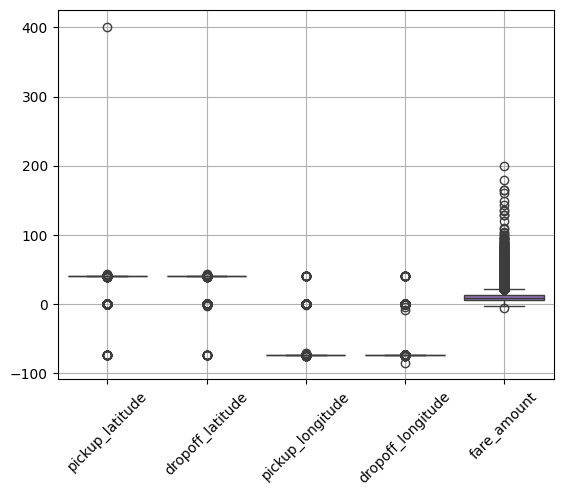

In [ ]:
sns.boxplot(taxi[['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude', 'fare_amount']])
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
# удаление выбросов или отрицательных значений тарифов
data = taxi.query('pickup_latitude > 40.7 and pickup_latitude < 40.8 and ' +
                  'dropoff_latitude > 40.7 and dropoff_latitude < 40.8 and ' +
                  'pickup_longitude > -74 and pickup_longitude < -73.9 and ' +
                  'dropoff_longitude > -74 and dropoff_longitude < -73.9 and ' +
                  'fare_amount > 0')

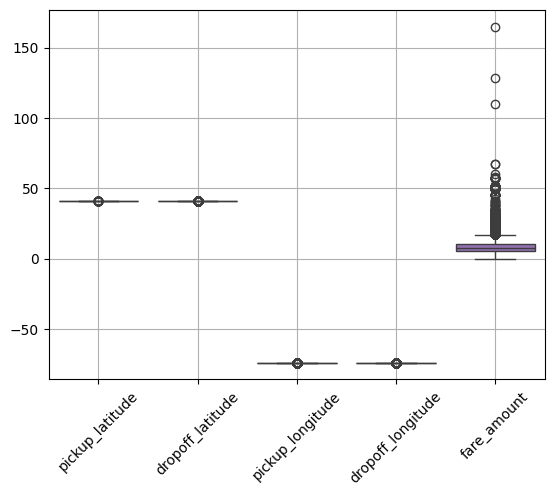

In [ ]:
sns.boxplot(data[['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude', 'fare_amount']])
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
y = taxi.fare_amount

base_features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
X = taxi[base_features]

In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
first_model = RandomForestRegressor(n_estimators=50, random_state=1).fit(train_X, train_y)

In [ ]:
perm1 = PermutationImportance(first_model, random_state=100).fit(val_X, val_y)
eli5.show_weights(perm1, feature_names=val_X.columns.tolist())

Weight,Feature
0.7952 ± 0.0295,dropoff_latitude
0.7009 ± 0.0197,pickup_longitude
0.6886 ± 0.0114,dropoff_longitude
0.4135 ± 0.0098,pickup_latitude
0.0017 ± 0.0027,passenger_count


In [ ]:
# предсказание 1 значения
rand = random.randint(1, len(val_X))
eli5.show_prediction(first_model, val_X.iloc[rand], show_feature_values=True)

In [ ]:
# новые признаки
taxi['abs_lon_change'] = abs(taxi.dropoff_longitude - taxi.pickup_longitude)
taxi['abs_lat_change'] = abs(taxi.dropoff_latitude - taxi.pickup_latitude)

In [ ]:
taxi.head(2)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_lon_change,abs_lat_change
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,0.002701,0.009041
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1,0.036780,0.070701


In [ ]:
features_2  = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
               'dropoff_latitude', 'abs_lat_change', 'abs_lon_change']

X = taxi[features_2]
new_train_X, new_test_X, new_train_y, new_test_y = train_test_split(X, y, random_state=123)
second_model = RandomForestRegressor(n_estimators=30, random_state=1).fit(new_train_X, new_train_y)

In [ ]:
perm2 = PermutationImportance(second_model, random_state=111).fit(new_test_X, new_test_y)
eli5.show_weights(perm2, feature_names = new_test_X.columns.tolist())

Weight,Feature
0.7634 ± 0.0257,abs_lon_change
0.3946 ± 0.0217,abs_lat_change
0.1242 ± 0.0073,pickup_latitude
0.0743 ± 0.0102,dropoff_longitude
0.0342 ± 0.0062,pickup_longitude
0.0328 ± 0.0042,dropoff_latitude


In [ ]:
rand = random.randint(1, len(new_test_X))
eli5.show_prediction(second_model, new_test_X.iloc[rand])

### Частичные графики (Partial Plots)

In [ ]:
data = pd.read_csv('FIFA 2018 Statistics.csv')

In [ ]:
y = (data['Man of the Match'] == "Yes")
feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[feature_names]

In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=111)
tree_model = DecisionTreeClassifier(random_state=0, max_depth=5, min_samples_split=5).fit(train_X, train_y)

In [ ]:
from sklearn import tree
import graphviz

Как читать график
- Листья с потомками показывают свой критерий разделения вверху.
- Пара значений внизу показывает количество значений False и True для цели соответственно, точек данных в этом узле дерева.

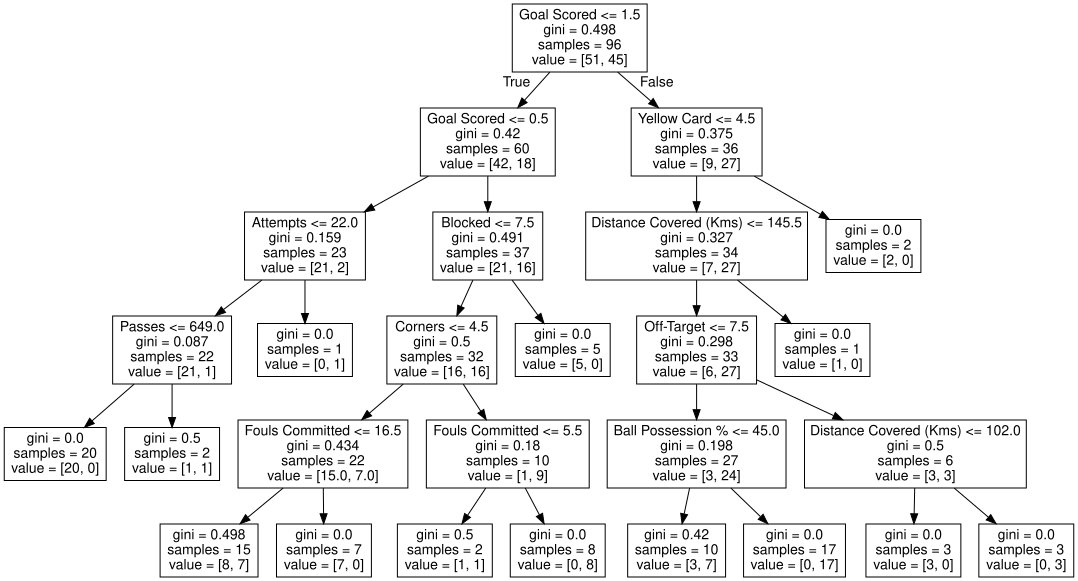

In [ ]:
tree_graph = tree.export_graphviz(tree_model, out_file=None, feature_names=feature_names)
graphviz.Source(tree_graph)

Код для создания графика частичной зависимости с использованием библиотеки scikit-learn.

Модуль sklearn.inspection предоставляет удобную функцию from_estimator для создания графиков односторонней и двусторонней частичной зависимости.

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

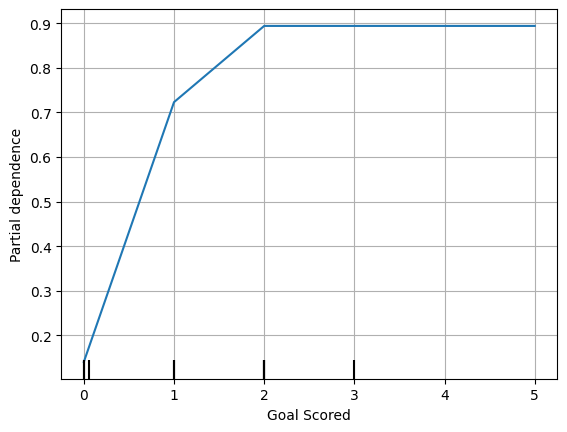

In [ ]:
disp1 = PartialDependenceDisplay.from_estimator(tree_model, val_X, ['Goal Scored'])
plt.grid()
plt.show()

Интерпретация графика:

Ось Y интерпретируется как изменение прогноза по сравнению с тем, что было бы предсказано на базовой линии или самом левом значении.

Синяя область обозначает интервал доверия.

Из этого конкретного графика видно, что забитый гол существенно увеличивает шансы на победу в номинации «Игрок матча». Но дополнительные голы, по-видимому, не оказывают существенного влияния на прогнозы.

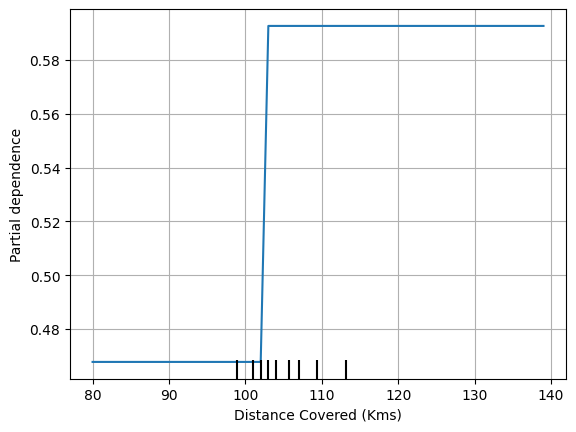

In [ ]:
feature_to_plot = 'Distance Covered (Kms)'
disp2 = PartialDependenceDisplay.from_estimator(tree_model, val_X, [feature_to_plot])
plt.grid()
plt.show()

Этот график кажется слишком простым, чтобы представлять реальность. Но это потому, что модель очень проста.

Можно легко сравнить структуру или последствия различных моделей. Вот тот же график с моделью Random Forest.

In [ ]:
rf_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

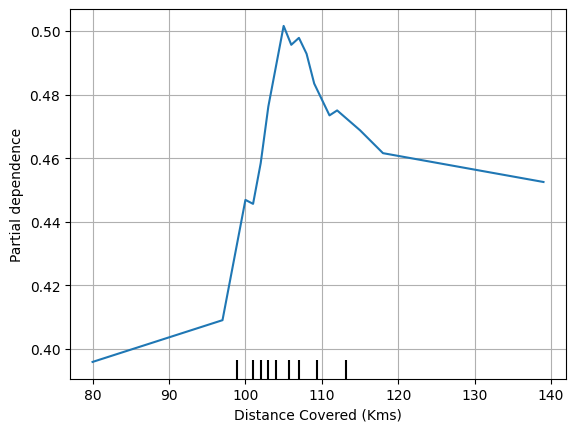

In [ ]:
disp3 = PartialDependenceDisplay.from_estimator(rf_model, val_X, [feature_to_plot])
plt.grid()
plt.show()

Эта модель считает, что больше шансов выиграть звание игрока матча, если игроки пробегут в общей сложности 100 км за игру. Хотя гораздо большее количество пробежек приводит к более низким прогнозам.

В целом, плавная форма этой кривой кажется более правдоподобной, чем ступенчатая функция из модели дерева решений. Этот набор данных достаточно мал, поэтому нужно быть осторожными в интерпретации модели.

⏩ 2D графики частичной зависимости.

Если интересно взаимодействие между признаками, 2D графики частичной зависимости также полезны.

Снова будет использоваться модель дерева решений для этого графика. Это создаст чрезвычайно простой график, но всё-таки можно сопоставить то, что на графике, с самим деревом.

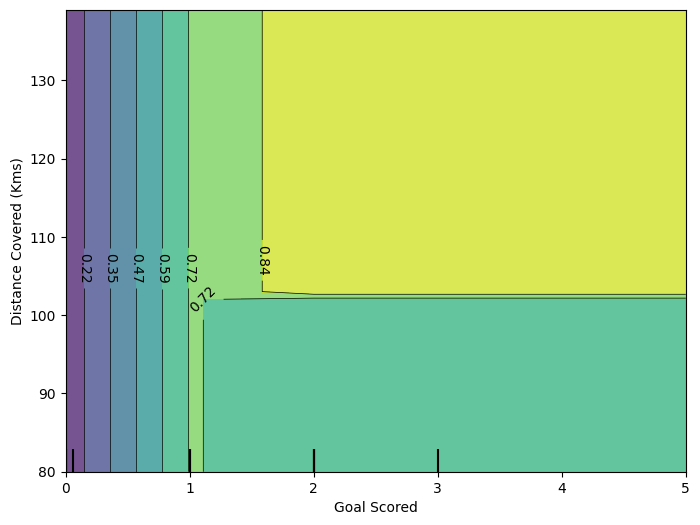

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
f_names = [('Goal Scored', 'Distance Covered (Kms)')]
# аналогично предыдущему графику PDP, за исключением использования кортежа признаков вместо одного признака
disp4 = PartialDependenceDisplay.from_estimator(tree_model, val_X, f_names, ax=ax)
plt.show()

Этот график показывает прогнозы для любой комбинации забитых голов и пройденного расстояния.

Например, самые высокие прогнозы, когда команда забивает хотя бы 1 гол и пробегает общее расстояние, близкое к 100 км. Если они не забивают голы, пройденное расстояние не имеет значения.
Но расстояние может повлиять на прогнозы, если они забивают голы.

In [ ]:
df = pd.read_csv('Taxi.csv')

In [ ]:
# избавляемся от выбросов
df= df.query('pickup_latitude > 40.7 and pickup_latitude < 40.8 and ' +
              'dropoff_latitude > 40.7 and dropoff_latitude < 40.8 and ' +
              'pickup_longitude > -74 and pickup_longitude < -73.9 and ' +
              'dropoff_longitude > -74 and dropoff_longitude < -73.9 and ' +
              'fare_amount > 0')

In [ ]:
y = df.fare_amount

base_features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
X = df[base_features]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=123)
first_model = RandomForestRegressor(n_estimators=30, random_state=123).fit(train_X, train_y)
print("Data sample:")
df.head(3)

Data sample:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


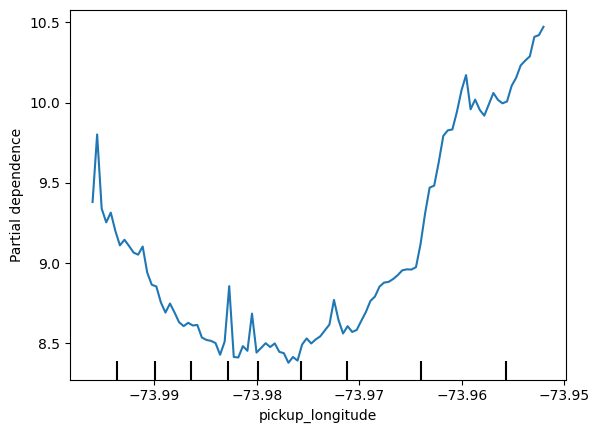

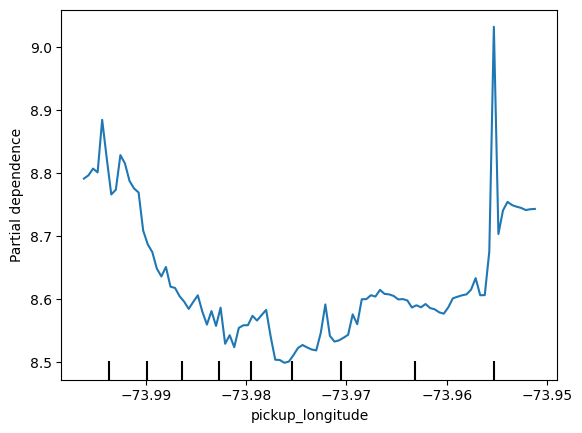

In [ ]:
feat_name = 'pickup_longitude'
PartialDependenceDisplay.from_estimator(first_model, val_X, [feat_name])
plt.show()

df['abs_lon_change'] = df.dropoff_longitude - df.pickup_longitude
df['abs_lat_change'] = df.dropoff_latitude - df.pickup_latitude

features_2  = ['pickup_longitude','pickup_latitude', 'dropoff_longitude',
               'dropoff_latitude', 'abs_lat_change', 'abs_lon_change']

X = df[features_2]
new_train_X, new_val_X, new_train_y, new_val_y = train_test_split(X, y, random_state=111)
second_model = RandomForestRegressor(n_estimators=30, random_state=111).fit(new_train_X, new_train_y)

feat_name = 'pickup_longitude'
disp = PartialDependenceDisplay.from_estimator(second_model, new_val_X, [feat_name])
plt.show()

👆 Разница в том, что график частичной зависимости стал меньше (тот, который нижний). Оба графика имеют наименьшее вертикальное значение 8,5. Но наибольшее вертикальное значение на верхнем графике составляет около 10,7, а на нижнем графике — ниже 9,1. Другими словами, если контролировать абсолютное пройденное расстояние, то pickup_longitude оказывает меньшее влияние на прогнозы.

### SHAP values

In [ ]:
data = pd.read_csv('FIFA 2018 Statistics.csv')

In [ ]:
data['Man of the Match'].head()

,Man of the Match
0,Yes
1,No
2,No
3,Yes
4,No


In [ ]:
len(data.columns)

27

In [ ]:
# из строки "Yes"/"No" в булев тип
y = (data['Man of the Match'] == "Yes")
feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[feature_names]

In [ ]:
y.head()

,Man of the Match
0,True
1,False
2,False
3,True
4,False


In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=11)
my_model = RandomForestClassifier(random_state=11).fit(train_X, train_y)

In [ ]:
# значения SHAP для 1 строки (например, строку 5), но можно и несколько строк
row_to_show = 5
data_for_prediction = val_X.iloc[row_to_show,:]
data_for_prediction_array = data_for_prediction.values.reshape(1, -1)

my_model.predict_proba(data_for_prediction_array)

array([[0.46, 0.54]])

Вероятность того, что игрок команды выиграет награду, составляет 54 %.

Теперь нужно получить значения SHAP для этого одного прогноза.

In [ ]:
import shap

In [ ]:
from IPython.display import display

In [ ]:
# создание объекта, который может вычислять значения SHAP --  shap.TreeExplainer(my_model)
explainer = shap.Explainer(my_model)

# подсчёт значений SHAP
shap_values = explainer.shap_values(data_for_prediction)

In [ ]:
explainer.expected_value, shap_values.shape, data_for_prediction.shape

(array([0.4915625, 0.5084375]), (18, 2), (18,))

Объект shap_values — это список с двумя массивами. Первый массив — это значения SHAP для отрицательного результата (не выиграть награду), а второй массив — это список значений SHAP для положительного результата (выиграть награду). Обычно говорят о прогнозах с точки зрения прогнозирования положительного результата, поэтому нужны значения SHAP для положительных результатов (shap_values[1] ниже).

In [ ]:
explainer.expected_value.shape, shap_values[:,1].shape, data_for_prediction.shape, shap_values.dtype

((2,), (18,), (18,), dtype('float64'))

In [ ]:
shap_values[:,1]

array([ 0.11432781,  0.004234  , -0.0303057 ,  0.01179343,  0.00063936,
        0.01798912,  0.00059291, -0.00817557,  0.02317579, -0.00607182,
       -0.00372757, -0.02932845, -0.04740802, -0.01777018, -0.00216369,
        0.        ,  0.0015301 ,  0.00223098])

cmap='RdBu'


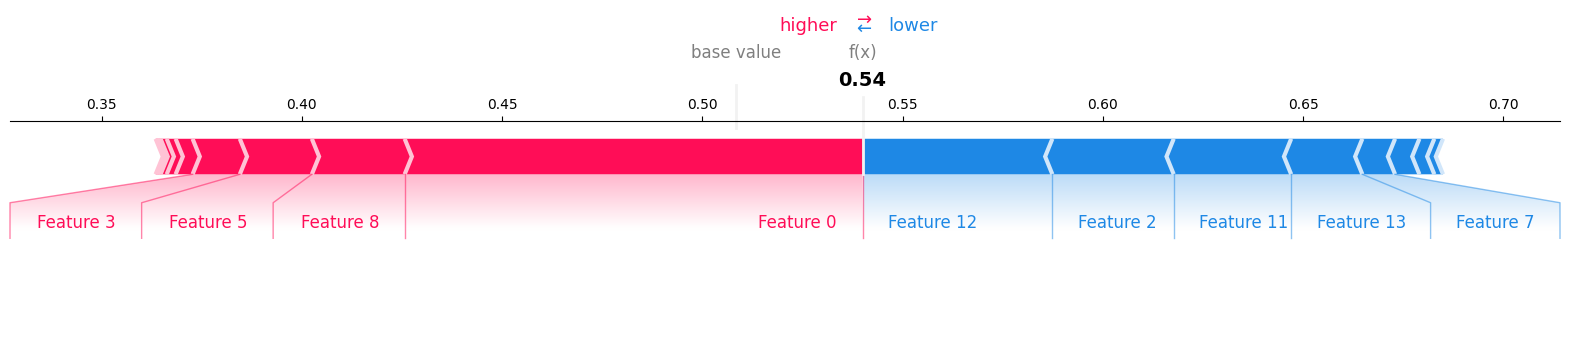

None

cmap='GnPR'


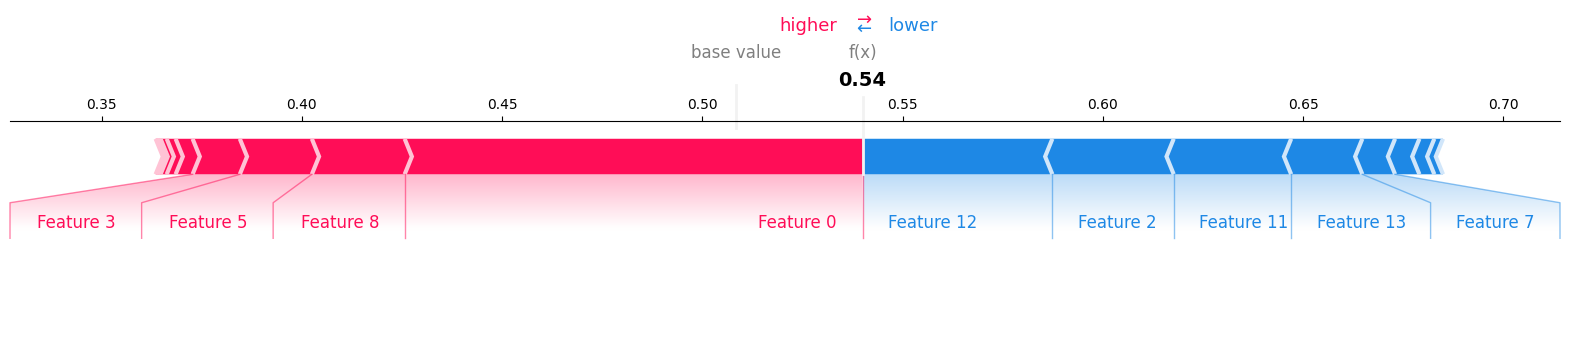

None

cmap='CyPU'


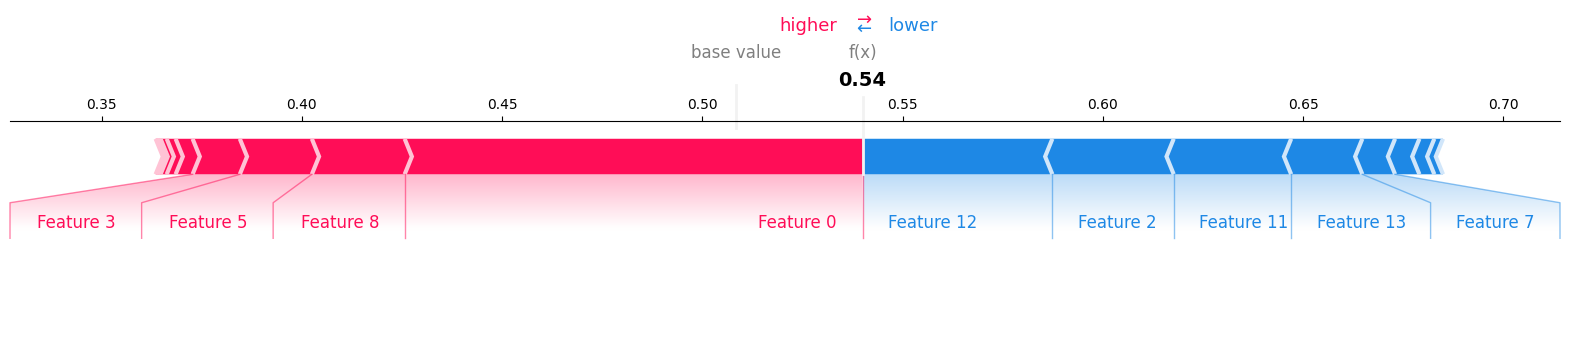

None

cmap='PkYg'


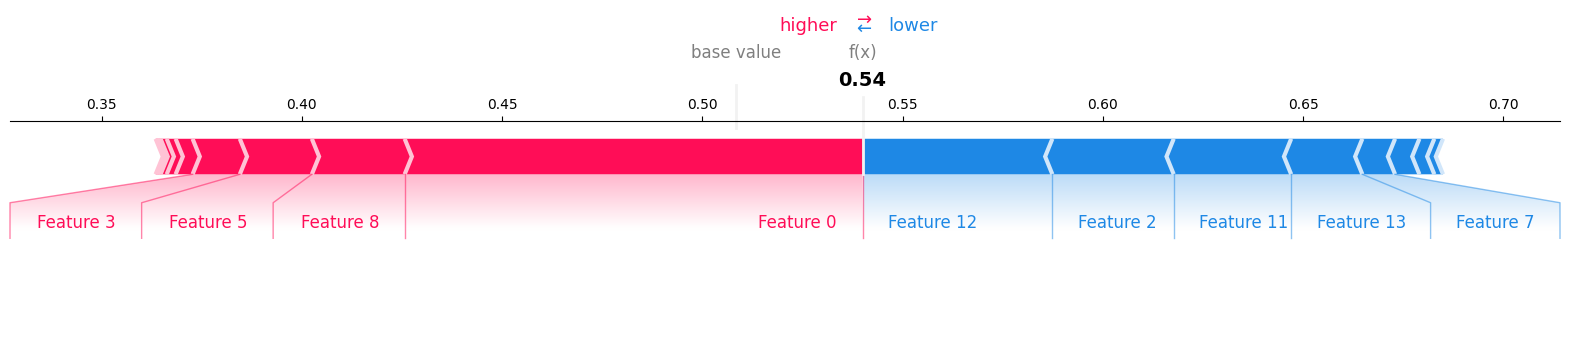

None

cmap='DrDb'


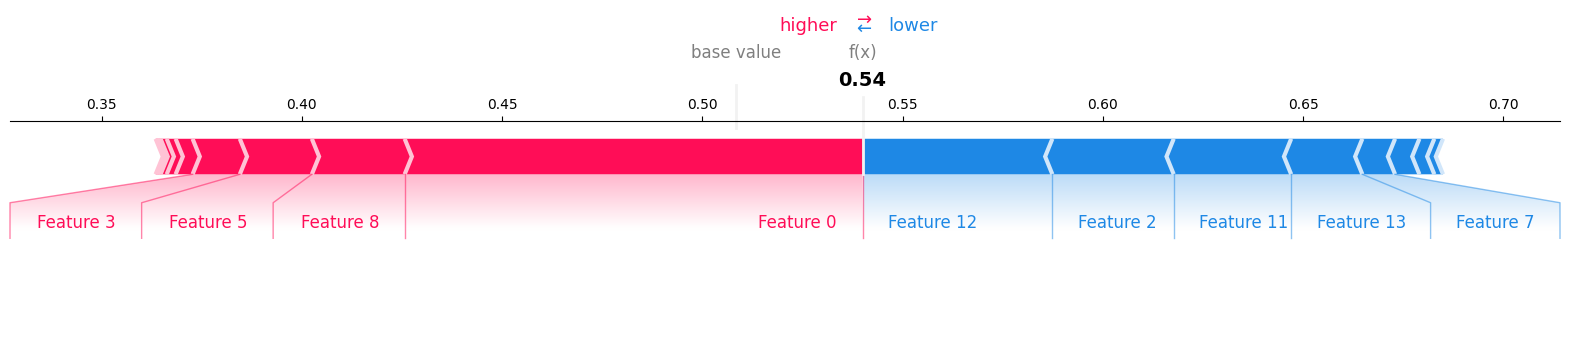

None

cmap='LpLb'


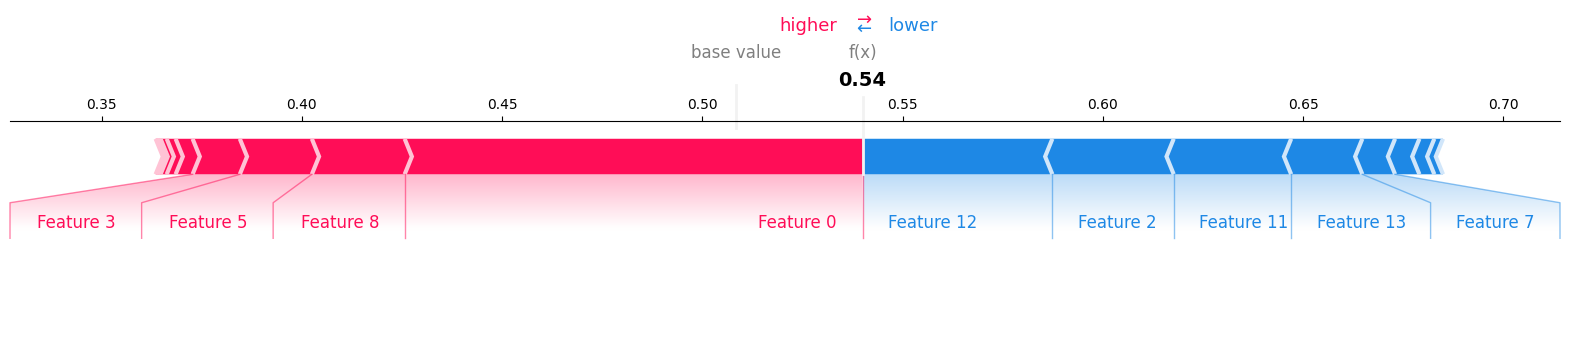

None

cmap='YlDp'


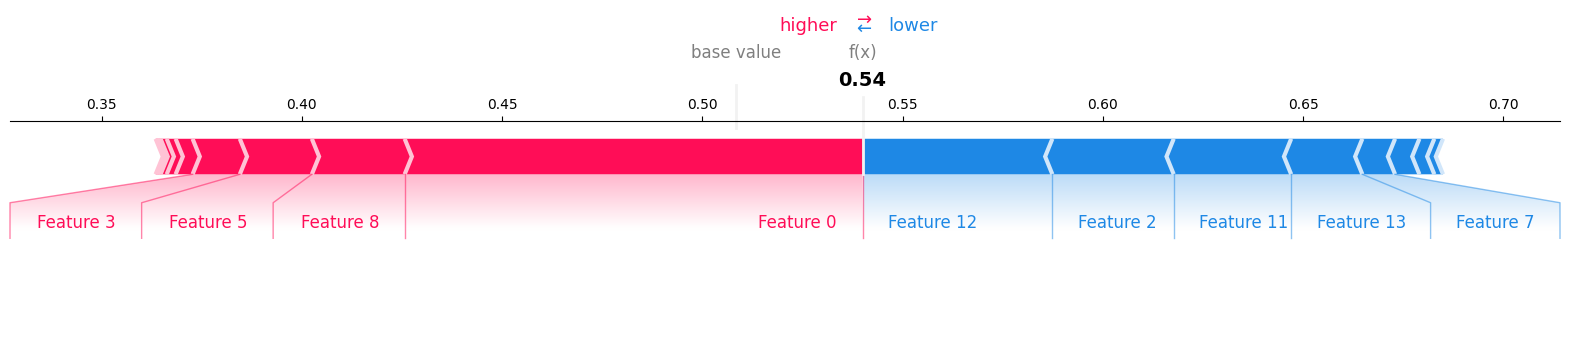

None

cmap='OrId'


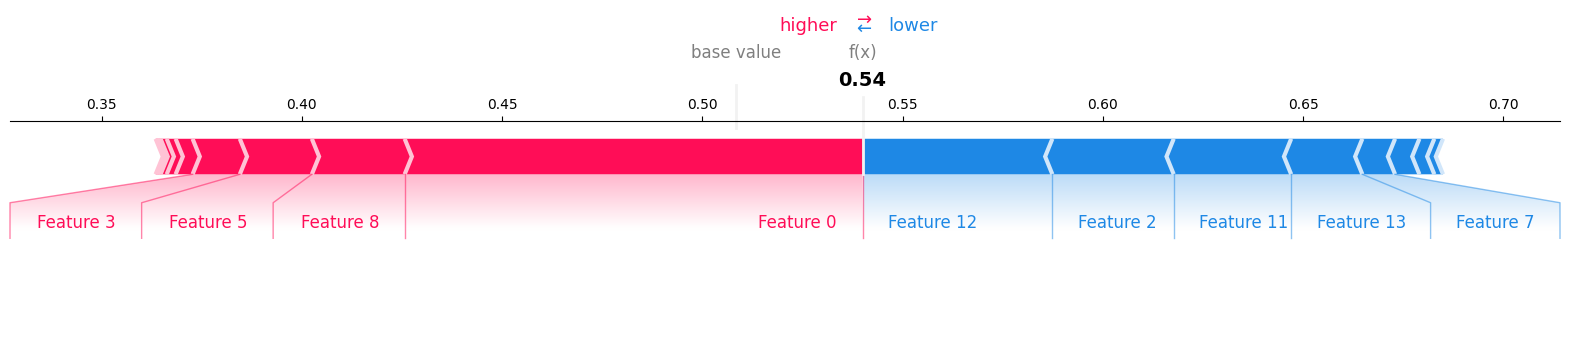

None

In [ ]:
"""
for cmap in ("RdBu",
            "GnPR",
            "CyPU",
            "PkYg",
            "DrDb",
            "LpLb",
            "YlDp",
            "OrId"):
    print(f"{cmap=}")
    display(shap.force_plot(explainer.expected_value[1], shap_values[:,1], matplotlib=True, plot_cmap=cmap))
"""

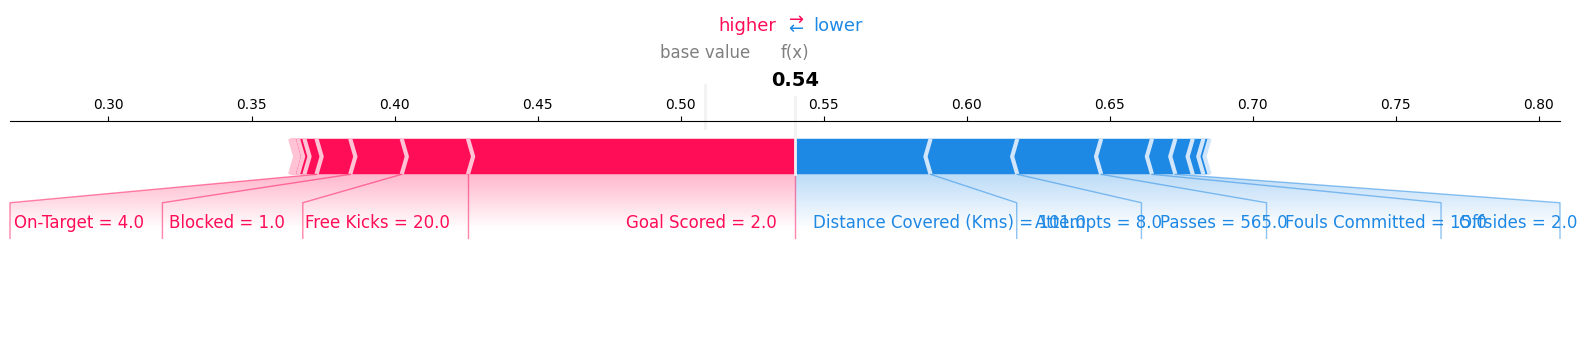

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[:,1], data_for_prediction, matplotlib=True, plot_cmap='YlDp')

`shap.DeepExplainer` работает с моделями глубокого обучения.

`shap.KernelExplainer` работает со всеми моделями, хотя он медленнее других объяснений и предлагает приближение, а не точные значения Shap.
Вот пример использования KernelExplainer для получения похожих результатов. Результаты не идентичны, потому что KernelExplainer дает приблизительный результат. Но результаты говорят об одном и том же.

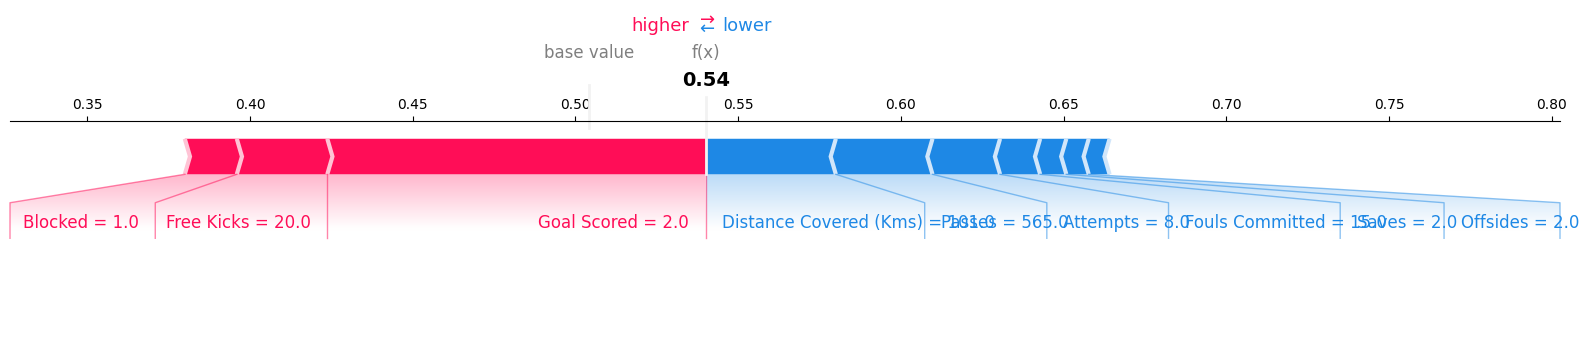

In [ ]:
# Kernel SHAP для объяснения прогнозов
shap.initjs()
k_explainer = shap.KernelExplainer(my_model.predict_proba, train_X)
k_shap_values = k_explainer.shap_values(data_for_prediction)
shap.force_plot(k_explainer.expected_value[1], k_shap_values[:,1], data_for_prediction, matplotlib=True, plot_cmap='YlDp')

#### Итоговое задание

In [ ]:
df = pd.read_csv('Hospital.csv')

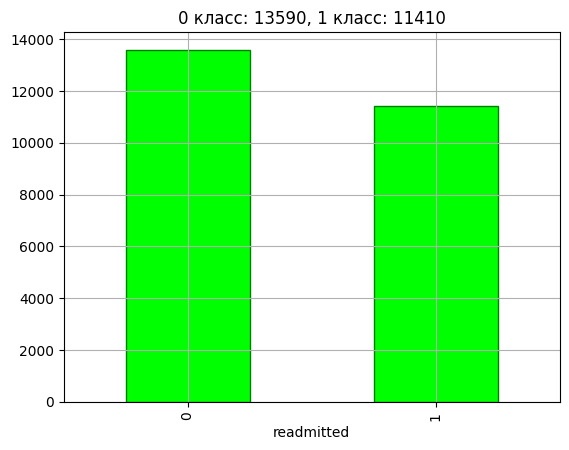

In [ ]:
# целевая переменная
df['readmitted'].value_counts().plot.bar(color='lime', edgecolor='green')
plt.title(f"0 класс: {df['readmitted'].value_counts()[0]}, 1 класс: {df['readmitted'].value_counts()[1]}")
plt.grid()
plt.show()

In [ ]:
df.columns

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'race_Caucasian',
       'race_AfricanAmerican', 'gender_Female', 'age_[70-80)', 'age_[60-70)',
       'age_[50-60)', 'age_[80-90)', 'age_[40-50)', 'payer_code_?',
       'payer_code_MC', 'payer_code_HM', 'payer_code_SP', 'payer_code_BC',
       'medical_specialty_?', 'medical_specialty_InternalMedicine',
       'medical_specialty_Emergency/Trauma',
       'medical_specialty_Family/GeneralPractice',
       'medical_specialty_Cardiology', 'diag_1_428', 'diag_1_414',
       'diag_1_786', 'diag_2_276', 'diag_2_428', 'diag_2_250', 'diag_2_427',
       'diag_3_250', 'diag_3_401', 'diag_3_276', 'diag_3_428',
       'max_glu_serum_None', 'A1Cresult_None', 'metformin_No',
       'repaglinide_No', 'nateglinide_No', 'chlorpropamide_No',
       'glimepiride_No', 'acetohexamide_No', 'glipizide_No', 'glyburide_No',
     

In [ ]:
df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race_Caucasian,race_AfricanAmerican,...,citoglipton_No,insulin_No,glyburide-metformin_No,glipizide-metformin_No,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-pioglitazone_No,change_No,diabetesMed_Yes,readmitted
0,14,41,0,11,0,0,0,6,True,False,...,True,True,True,True,True,True,True,True,True,0
1,2,30,0,12,0,0,1,9,True,False,...,True,False,True,True,True,True,True,False,True,1
2,5,66,0,22,1,0,2,9,True,False,...,True,True,True,True,True,True,True,True,True,1
3,3,63,0,8,0,0,0,8,True,False,...,True,True,True,True,True,True,True,True,True,1
4,5,40,0,6,0,0,1,9,True,False,...,True,True,True,True,True,True,True,True,False,0


Столбцы со словом diag указывают диагностический код заболевания, с которым был госпитализирован пациент. Например, diag_1_428 означает, что врач сказал, что его первый диагноз заболевания — номер «428». Какому заболеванию соответствует 428? Можно поискать в кодовой книге, но без дополнительной медицинской подготовки это вряд ли поможет.

Имена столбцов, такие как glimepiride_No, означают, что у пациента не было лекарства glimepiride. Если эта функция имела значение False, то пациент принимал лекарство glimepiride.

Функции, имена которых начинаются с medical_specialty, описывают специальность врача, наблюдающего пациента.

Все значения в этих полях — True или False.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 65 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   time_in_hospital                          25000 non-null  int64
 1   num_lab_procedures                        25000 non-null  int64
 2   num_procedures                            25000 non-null  int64
 3   num_medications                           25000 non-null  int64
 4   number_outpatient                         25000 non-null  int64
 5   number_emergency                          25000 non-null  int64
 6   number_inpatient                          25000 non-null  int64
 7   number_diagnoses                          25000 non-null  int64
 8   race_Caucasian                            25000 non-null  bool 
 9   race_AfricanAmerican                      25000 non-null  bool 
 10  gender_Female                             25000 non-null  

In [ ]:
df.isna().sum()

,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
...,...
metformin-rosiglitazone_No,0
metformin-pioglitazone_No,0
change_No,0
diabetesMed_Yes,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
x = df.drop(columns='readmitted')
y = df['readmitted']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=99)

In [ ]:
x_train.shape, x_test.shape

((18750, 64), (6250, 64))

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(x_train, y_train)

In [ ]:
perm = PermutationImportance(model, random_state=1).fit(x_test, y_test)
eli5.show_weights(perm, feature_names = x_test.columns.tolist())

Weight,Feature
0.0474 ± 0.0104,number_inpatient
0.0108 ± 0.0082,number_emergency
0.0062 ± 0.0043,number_outpatient
0.0026 ± 0.0043,metformin_No
0.0013 ± 0.0032,glipizide_No
0.0012 ± 0.0005,medical_specialty_Emergency/Trauma
0.0008 ± 0.0008,repaglinide_No
0.0008 ± 0.0010,diag_3_401
0.0006 ± 0.0012,max_glu_serum_None
0.0004 ± 0.0021,payer_code_SP


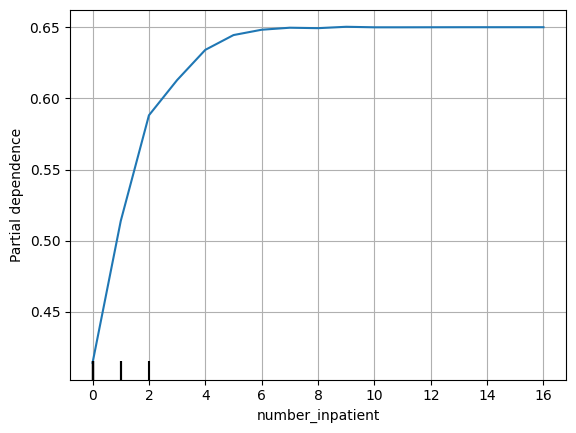

In [ ]:
feature_name = 'number_inpatient'
PartialDependenceDisplay.from_estimator(model, x_test, [feature_name])
plt.grid()
plt.show()

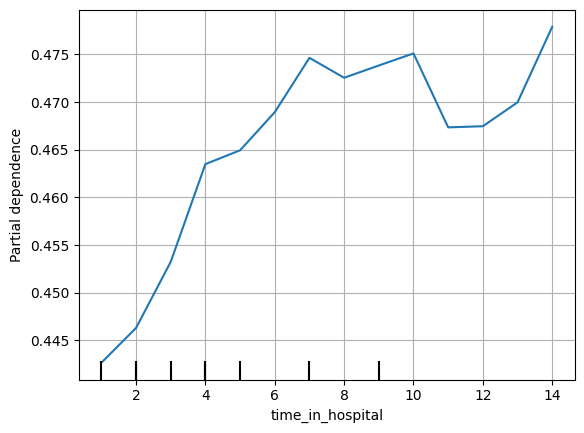

In [ ]:
feature_name = 'time_in_hospital'
PartialDependenceDisplay.from_estimator(model, x_test, [feature_name])
plt.grid()
plt.show()
# Кажется, что 'time_in_hospital' вообще не имеет значения. Разница между самым низким значением на графике
# частичной зависимости и самым высоким значением составляет около 5%.

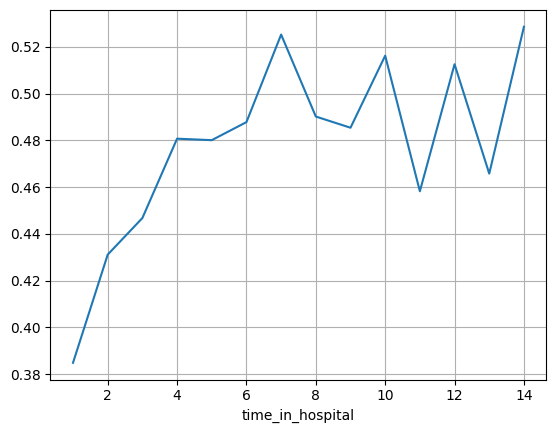

In [ ]:
all_train = pd.concat([x_train, y_train], axis=1)
all_train.groupby(['time_in_hospital']).mean().readmitted.plot()
plt.grid()
plt.show()

# Средний показатель повторной госпитализации для каждого time_in_hospital.
# Разделить данные проверки, а не использовать все исходные данные.

In [ ]:
data_for_prediction = x_test.iloc[0,:]

explainer = shap.Explainer(model)
shap_values = explainer.shap_values(data_for_prediction)

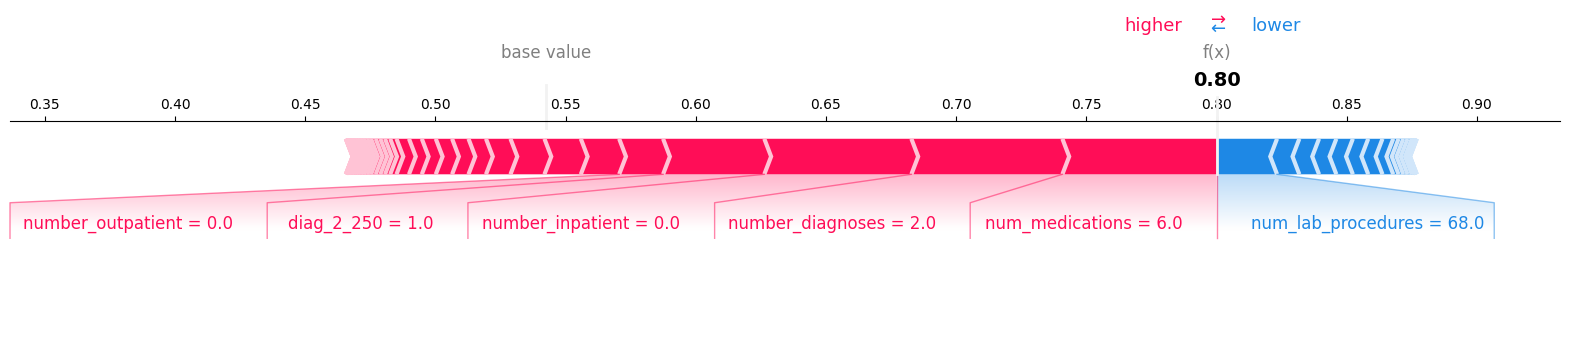

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[:,0], data_for_prediction, matplotlib=True)

### Advanced Uses of SHAP Values

https://www.kaggle.com/code/dansbecker/advanced-uses-of-shap-values

Ширина диапазона эффектов не является разумным приближением к важности перестановки. В этом отношении ширина диапазона не очень хорошо соответствует интуитивному чувству «важности», поскольку ее можно определить всего по нескольким выбросам. Однако, если все точки на графике широко разбросаны друг от друга, это разумный признак того, что важность перестановки высока. Поскольку диапазон эффектов настолько чувствителен к выбросам, важность перестановки является лучшей мерой того, что в целом важно для модели.

`Когда красные и синие точки на графике перемешаны:`

Перемешивание предполагает, что иногда увеличение этого признака приводит к более высоким прогнозам, а иногда к более низким прогнозам. Другими словами, как высокие, так и низкие значения признака могут иметь как положительные, так и отрицательные эффекты на прогноз. Наиболее вероятным объяснением этого «перемешивания» эффектов является то, что переменная имеет эффект взаимодействия с другими переменными. Например, могут быть некоторые диагнозы, для которых хорошо иметь много лабораторных процедур, и другие диагнозы, которые предполагают повышенный риск. Мы пока не знаем, какой еще признак взаимодействует с таким признаком, хотя мы могли бы исследовать это с помощью графиков зависимости вклада SHAP (SHAP contribution dependence plots).

График состоит из множества точек. Каждая точка имеет три характеристики:
- Вертикальное расположение показывает, какую функцию она отображает
- Цвет показывает, была ли эта функция высокой или низкой для этой строки набора данных
- Горизонтальное расположение показывает, вызвало ли влияние этого значения более высокий или низкий прогноз.

In [ ]:
data = pd.read_csv('FIFA 2018 Statistics.csv')

In [ ]:
y = (data['Man of the Match'] == "Yes")
feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[feature_names]

In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

In [ ]:
train_X.shape, val_X.shape

((96, 18), (32, 18))

In [ ]:
explainer = shap.TreeExplainer(my_model)
# Calculate shap_values for all of val_X rather than a single row, to have more data for plot.
shap_values = explainer(val_X)

- explainer(X) - объект Explanation
- explainer.shap_values(X) - объект ndarray

In [ ]:
shap_values.shape

(32, 18, 2)

In [ ]:
shap_values[0]

.values =
array([[ 2.14045350e-01, -2.14045350e-01],
       [-2.11501004e-02,  2.11501004e-02],
       [ 4.66721751e-02, -4.66721751e-02],
       [ 2.28475677e-02, -2.28475677e-02],
       [-1.08748824e-02,  1.08748824e-02],
       [-1.92050793e-02,  1.92050793e-02],
       [-3.46666728e-03,  3.46666728e-03],
       [-4.41675941e-04,  4.41675941e-04],
       [ 3.20476249e-02, -3.20476249e-02],
       [ 2.89423189e-03, -2.89423189e-03],
       [-1.00742194e-01,  1.00742194e-01],
       [-2.77881175e-02,  2.77881175e-02],
       [-1.40882409e-02,  1.40882409e-02],
       [-2.55323026e-03,  2.55323026e-03],
       [ 1.52616934e-03, -1.52616934e-03],
       [-4.84691547e-05,  4.84691547e-05],
       [-4.00852716e-04,  4.00852716e-04],
       [ 1.97639121e-03, -1.97639121e-03]])

.base_values =
array([0.49875, 0.50125])

.data =
array([  0,  60,   9,   3,   5,   1,   5,   1,   7,   4,  90, 629, 102,
        16,   3,   0,   0,   0])

Вывод shap_values состоит из 3 компонентов:
- values — SHAP-значения для каждого из прогнозов.
- data — значения для бинарных признаков.
- base_values — базовое значение, одинаковое для каждого прогноза.

Это средний прогнозируемый логарифм отношения шансов.

In [ ]:
# Значения SHAP для первого предсказания можно рассмотреть более подробно

print(shap_values.values[0])

[[ 2.14045350e-01 -2.14045350e-01]
 [-2.11501004e-02  2.11501004e-02]
 [ 4.66721751e-02 -4.66721751e-02]
 [ 2.28475677e-02 -2.28475677e-02]
 [-1.08748824e-02  1.08748824e-02]
 [-1.92050793e-02  1.92050793e-02]
 [-3.46666728e-03  3.46666728e-03]
 [-4.41675941e-04  4.41675941e-04]
 [ 3.20476249e-02 -3.20476249e-02]
 [ 2.89423189e-03 -2.89423189e-03]
 [-1.00742194e-01  1.00742194e-01]
 [-2.77881175e-02  2.77881175e-02]
 [-1.40882409e-02  1.40882409e-02]
 [-2.55323026e-03  2.55323026e-03]
 [ 1.52616934e-03 -1.52616934e-03]
 [-4.84691547e-05  4.84691547e-05]
 [-4.00852716e-04  4.00852716e-04]
 [ 1.97639121e-03 -1.97639121e-03]]


<Figure size 640x480 with 0 Axes>

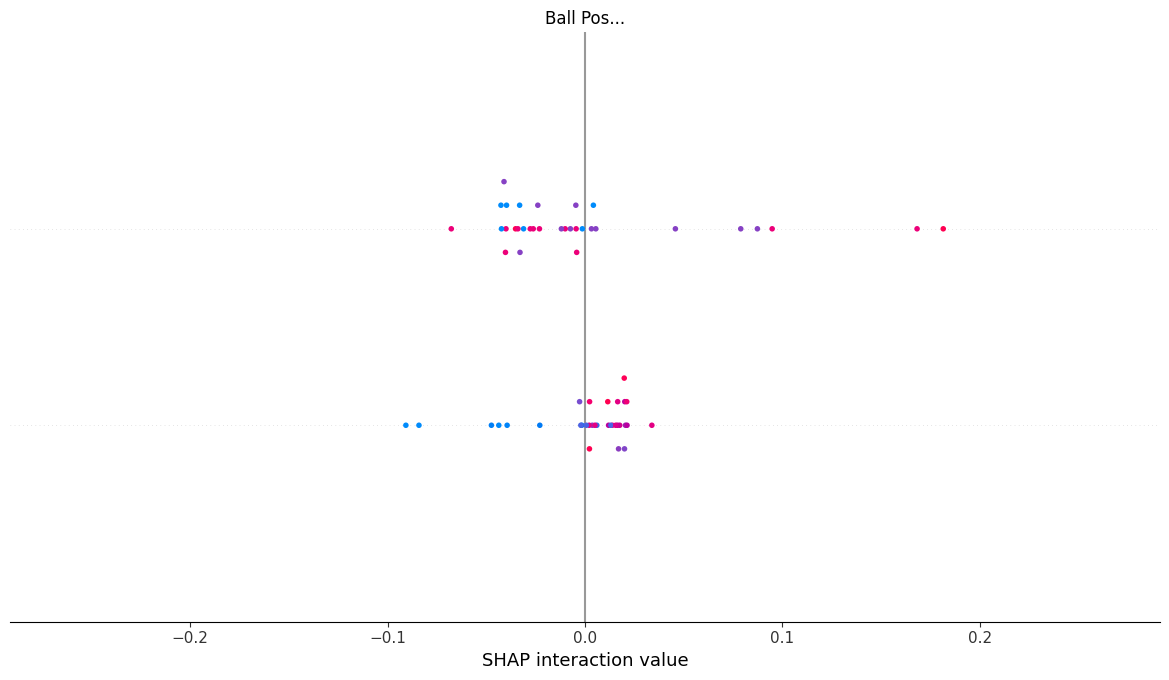

In [ ]:
shap.summary_plot(shap_values, val_X, plot_size=(13,9))

ValueError: x and y must be the same size

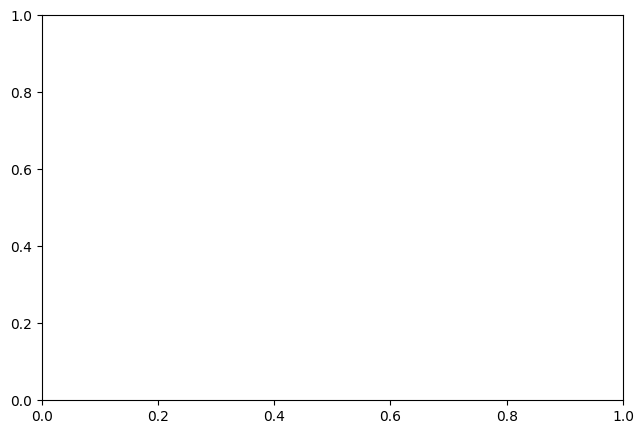

In [ ]:
shap.dependence_plot('Ball Possession %', shap_values, val_X, interaction_index="Goal Scored")

In [ ]:
for feature_name in val_X.columns:
  shap.dependence_plot(feature_name, shap_values, val_X, display_features=val_X)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 3

In [ ]:
shap_explainer = explainer(val_X)

In [ ]:
sh = explainer.shap_values(val_X)
type(sh)

numpy.ndarray

In [ ]:
shap_explainer.shape, type(shap_explainer)

((32, 18, 2), shap._explanation.Explanation)

In [ ]:
shap_explainer.values[0:3]

array([[[ 2.14045350e-01, -2.14045350e-01],
        [-2.11501004e-02,  2.11501004e-02],
        [ 4.66721751e-02, -4.66721751e-02],
        [ 2.28475677e-02, -2.28475677e-02],
        [-1.08748824e-02,  1.08748824e-02],
        [-1.92050793e-02,  1.92050793e-02],
        [-3.46666728e-03,  3.46666728e-03],
        [-4.41675941e-04,  4.41675941e-04],
        [ 3.20476249e-02, -3.20476249e-02],
        [ 2.89423189e-03, -2.89423189e-03],
        [-1.00742194e-01,  1.00742194e-01],
        [-2.77881175e-02,  2.77881175e-02],
        [-1.40882409e-02,  1.40882409e-02],
        [-2.55323026e-03,  2.55323026e-03],
        [ 1.52616934e-03, -1.52616934e-03],
        [-4.84691547e-05,  4.84691547e-05],
        [-4.00852716e-04,  4.00852716e-04],
        [ 1.97639121e-03, -1.97639121e-03]],

       [[-8.83391460e-02,  8.83391460e-02],
        [-2.00116905e-02,  2.00116905e-02],
        [-2.76173642e-03,  2.76173642e-03],
        [-1.32580228e-02,  1.32580228e-02],
        [ 8.07933902e-03, -8.0

In [ ]:
shap_explainer[:, 'Ball Possession %'].shape

(32, 2)

In [ ]:
shap.plots.scatter(shap_explainer[:, 'Ball Possession %'])

DimensionError: The passed Explanation object has multiple columns. Please pass a single feature column to shap.plots.scatter like: shap_values[:, column]

In [ ]:
shap.plots.bar(shap_explainer)

IndexError: list index out of range

In [ ]:
shap.plots.waterfall(shap_explainer)

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (32, 18, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.